# Phase 5: Classification - Demand Risk Regimes

Phase 4 asked "exactly how many MW will this hour need." This phase asks a
narrower, more operational question: "is this upcoming hour Low, Normal,
Peak, or Critical demand?" A grid operator will often care more about this 
question as it's what actually triggers real decisions like
preparing demand-response programs and comes with genuinely
different success criteria than MAE/MAPE: precision, recall, and the
trade-off between them, especially given that the category we care about
catching most (Critical) will also be the rarest by construction.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

pd.set_option("display.max_columns", None)

train_df = pd.read_csv('../data/processed/train.csv', parse_dates=['datetime'])
test_2023 = pd.read_csv('../data/processed/test_2023.csv', parse_dates=['datetime'])
test_2024 = pd.read_csv('../data/processed/test_2024.csv', parse_dates=['datetime'])
test_2025 = pd.read_csv('../data/processed/test_2025.csv', parse_dates=['datetime'])

TARGET_COL = 'ontario_demand'
EXCLUDE_COLS = {
    'datetime', TARGET_COL, 'market_demand', 'hoep', 'temperature_c'
}
feature_cols = [c for c in train_df.columns if c not in EXCLUDE_COLS]
print(f"Reusing {len(feature_cols)} features from Phase 3/4, unchanged -- only the target changes.")

Reusing 28 features from Phase 3/4, unchanged -- only the target changes.


## 1. Defining the regime categories

Using demand percentiles to define four categories: Low (bottom 25%),
Normal (25th-75th percentile), Peak (75th-95th), and Critical (top 5%).
This is a reasonable, defensible split for this project's scope. A more
elaborate version could instead use IESO's own published demand-response
trigger thresholds.

**Critical leakage point:** the percentile thresholds themselves must be
computed from TRAINING data only, then applied unchanged to the test
years. Computing thresholds from the full dataset (including 2023-2025)
would let information about the test period's actual distribution leak
into how categories are defined in the first place.

In [ ]:
quantiles = train_df[TARGET_COL].quantile([0.25, 0.75, 0.95])
LOW_THRESHOLD, PEAK_THRESHOLD, CRITICAL_THRESHOLD = quantiles[0.25], quantiles[0.75], quantiles[0.95]

print(f"Low:      demand < {LOW_THRESHOLD:.0f} MW")
print(f"Normal:   {LOW_THRESHOLD:.0f} - {PEAK_THRESHOLD:.0f} MW")
print(f"Peak:     {PEAK_THRESHOLD:.0f} - {CRITICAL_THRESHOLD:.0f} MW")
print(f"Critical: demand > {CRITICAL_THRESHOLD:.0f} MW")


def assign_regime(demand_series):
    # Sort the thresholds defined above into their respective regime bins
    return pd.cut(
        demand_series,
        bins=[-np.inf, LOW_THRESHOLD, PEAK_THRESHOLD, CRITICAL_THRESHOLD, np.inf],
        labels=['Low', 'Normal', 'Peak', 'Critical'],
    )

train_df['regime'] = assign_regime(train_df[TARGET_COL])
test_2023['regime'] = assign_regime(test_2023[TARGET_COL])
test_2024['regime'] = assign_regime(test_2024[TARGET_COL])
test_2025['regime'] = assign_regime(test_2025[TARGET_COL])

train_df['regime'].value_counts()

Low:      demand < 14294 MW
Normal:   14294 - 18044 MW
Peak:     18044 - 20682 MW
Critical: demand > 20682 MW


regime
Normal      90425
Low         45221
Peak        36155
Critical     9040
Name: count, dtype: int64

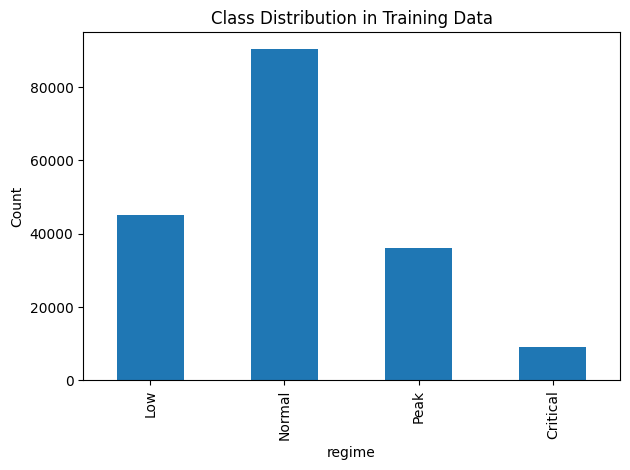

In [5]:
fig, ax = plt.subplots()
train_df['regime'].value_counts().reindex(['Low', 'Normal', 'Peak', 'Critical']).plot(kind='bar', ax=ax)
plt.title('Class Distribution in Training Data')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

As expected, Low and Normal dominate (this is exactly how percentile-based
thresholds work by construction) and Critical is rare. This imbalance is
the whole reason accuracy alone would be a misleading metric here -- a
model that always predicted "Normal" would still score close to 50%
accuracy while being completely useless for the thing we actually care
about: catching Critical hours.

## 2. Handling class imbalance

Rather than letting the model implicitly learn "just guess Normal most of
the time" (which minimizes overall error given how rare Critical is),
`compute_sample_weight` assigns higher weight to
under-represented classes during training. This effectively tells the model
"a mistake on a rare Critical hour costs more than a mistake on a common
Normal hour," which better matches how a real grid operator would actually
value these errors.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

param_distributions = {
    'max_depth': [3, 4, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 10],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2],
}

tscv = TimeSeriesSplit(n_splits=5)
all_sample_weights = compute_sample_weight('balanced', train_df['regime'])

# Using F1 scoring leads to a score that values all four classes equally, rather than indirectly
# weighting them by how common each class is. Plain accuracy (or an accuracy-weighted score)
# would let the search reward configurations that just get better at predicting the
# dominant Normal/Low classes while ignoring Critical which is exactly the failure
# that class balancing is meant to prevent
clf_search = RandomizedSearchCV(
    XGBClassifier(n_estimators=500, random_state=42, eval_metric='mlogloss'),
    param_distributions=param_distributions,
    n_iter=30,
    cv=tscv,
    scoring='f1_macro',
    random_state=42,
)
clf_search.fit(train_df[feature_cols], train_df['regime'].cat.codes, sample_weight=all_sample_weights)
print(clf_search.best_params_)

{'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 1, 'min_child_weight': 10, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.8}


In [9]:
xgb_fit_df = train_df[train_df['datetime'] < '2022-01-01']
xgb_val_df = train_df[train_df['datetime'] >= '2022-01-01']

sample_weights = compute_sample_weight('balanced', xgb_fit_df['regime'])

# Use the best parameters from the fitted XGBoost model
clf = XGBClassifier(
    **clf_search.best_params_,
    n_estimators=500,
    early_stopping_rounds=30,
    random_state=42,
    eval_metric='mlogloss',
)

clf.fit(
    xgb_fit_df[feature_cols], xgb_fit_df['regime'].cat.codes,
    sample_weight=sample_weights,
    eval_set=[(xgb_val_df[feature_cols], xgb_val_df['regime'].cat.codes)],
    verbose=False,
)

print(f"Best iteration: {clf.best_iteration}")

Best iteration: 492


## 3. A simple baseline for comparison

Same principle as comparing XGBoost against an LSTM in Phase 4: a result
only means something in contrast to a simpler alternative. Logistic
regression, with the same class balancing, is a reasonable, fast baseline
here.

In [ ]:
from sklearn.preprocessing import StandardScaler

baseline_scaler = StandardScaler()
baseline_scaler.fit(xgb_fit_df[feature_cols]) # only fit on train data

baseline = LogisticRegression(max_iter=1000, class_weight='balanced')
baseline.fit(baseline_scaler.transform(xgb_fit_df[feature_cols]), xgb_fit_df['regime'].cat.codes)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## 4. Evaluation - precision/recall/F1 per class, not just accuracy

`classification_report` breaks results down by class, which is exactly
what accuracy alone can't do. We'll pay particular attention to Critical's
Recall specifically. Of all the truly Critical hours, what fraction did
the model actually catch? Missing a real Critical hour (a false negative)
is generally more costly in a real grid-operations context than a false
alarm on a Peak hour, so recall on the rare class is arguably the single
most important number in the whole table.

=== XGBoost 2023 ===
              precision    recall  f1-score   support

         Low       0.84      0.92      0.88      2499
      Normal       0.90      0.83      0.86      4965
        Peak       0.68      0.73      0.70      1179
    Critical       0.59      0.76      0.66       117

    accuracy                           0.84      8760
   macro avg       0.75      0.81      0.78      8760
weighted avg       0.85      0.84      0.84      8760



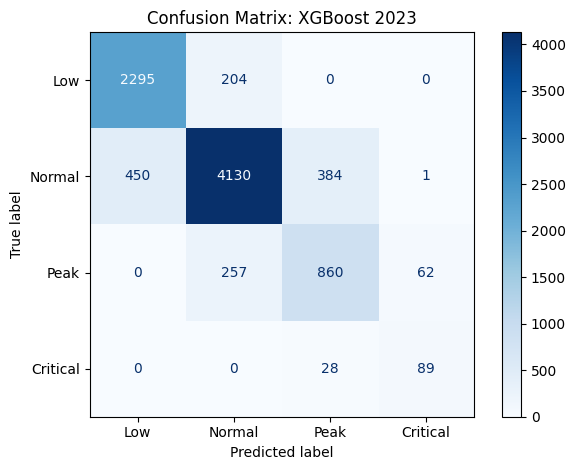

=== XGBoost 2024 ===
              precision    recall  f1-score   support

         Low       0.80      0.92      0.86      2193
      Normal       0.90      0.83      0.86      4891
        Peak       0.72      0.76      0.74      1453
    Critical       0.72      0.63      0.67       247

    accuracy                           0.84      8784
   macro avg       0.78      0.79      0.78      8784
weighted avg       0.84      0.84      0.84      8784



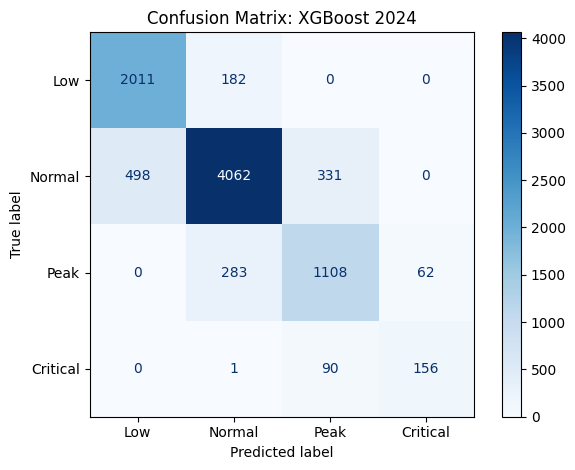

=== XGBoost 2025 (partial) ===
              precision    recall  f1-score   support

         Low       0.68      0.90      0.77       316
      Normal       0.90      0.88      0.89      1700
        Peak       0.88      0.83      0.85       807
    Critical       0.71      0.60      0.65        57

    accuracy                           0.86      2880
   macro avg       0.79      0.80      0.79      2880
weighted avg       0.87      0.86      0.86      2880



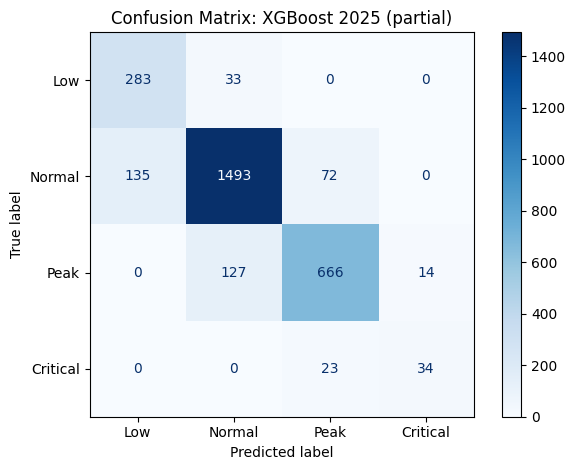

In [12]:
regime_labels = ['Low', 'Normal', 'Peak', 'Critical']

def evaluate_classifier(model, X, y_true_codes, label, is_baseline=False):
    preds_codes = model.predict(X)
    y_true = pd.Categorical.from_codes(y_true_codes, categories=regime_labels)
    y_pred = pd.Categorical.from_codes(preds_codes, categories=regime_labels)

    print(f"=== {label} ===")
    print(classification_report(y_true, y_pred, labels=regime_labels, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=regime_labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=regime_labels)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix: {label}')
    plt.tight_layout()
    plt.show()

for year_label, test_set in [('2023', test_2023), ('2024', test_2024), ('2025 (partial)', test_2025)]:
    evaluate_classifier(clf, test_set[feature_cols], test_set['regime'].cat.codes, f'XGBoost {year_label}')

=== Logistic Regression 2023 ===
              precision    recall  f1-score   support

         Low       0.82      0.90      0.86      2499
      Normal       0.91      0.79      0.84      4965
        Peak       0.62      0.79      0.70      1179
    Critical       0.57      0.90      0.70       117

    accuracy                           0.82      8760
   macro avg       0.73      0.84      0.77      8760
weighted avg       0.84      0.82      0.83      8760



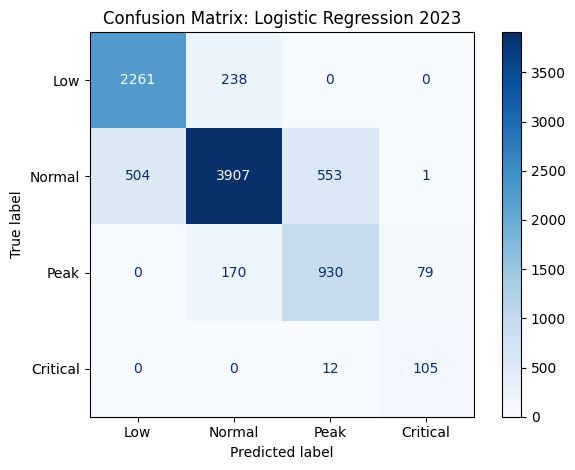

=== Logistic Regression 2024 ===
              precision    recall  f1-score   support

         Low       0.78      0.90      0.83      2193
      Normal       0.90      0.78      0.84      4891
        Peak       0.68      0.79      0.73      1453
    Critical       0.60      0.78      0.68       247

    accuracy                           0.81      8784
   macro avg       0.74      0.81      0.77      8784
weighted avg       0.83      0.81      0.82      8784



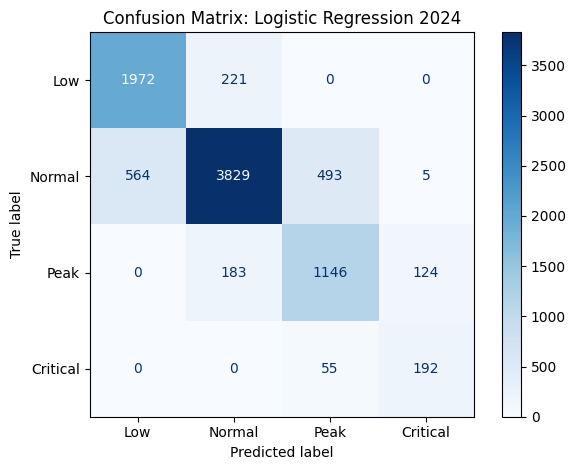

=== Logistic Regression 2025 (partial) ===
              precision    recall  f1-score   support

         Low       0.73      0.84      0.78       316
      Normal       0.92      0.80      0.86      1700
        Peak       0.72      0.78      0.75       807
    Critical       0.32      0.95      0.47        57

    accuracy                           0.80      2880
   macro avg       0.67      0.84      0.71      2880
weighted avg       0.83      0.80      0.81      2880



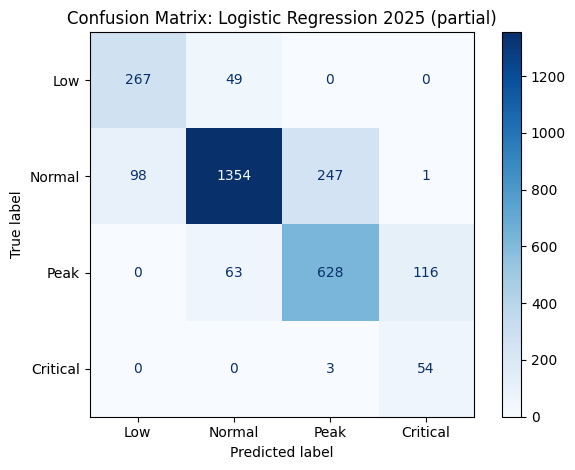

In [17]:
# Baseline comparison, 2023 only, for a quick sanity check against XGBoost
for year_label, test_set in [('2023', test_2023), ('2024', test_2024), ('2025 (partial)', test_2025)]:
    evaluate_classifier(baseline, baseline_scaler.transform(test_set[feature_cols]), test_set['regime'].cat.codes, f'Logistic Regression {year_label}')

## 5. Feature importance for the classifier

Worth checking whether the same features that mattered for regression
(Phase 4) also matter for classification. They often overlap heavily,
but not always; a feature can matter a lot for pinning down the exact MW
value while contributing less to which broad category an hour falls into,
or vice versa.

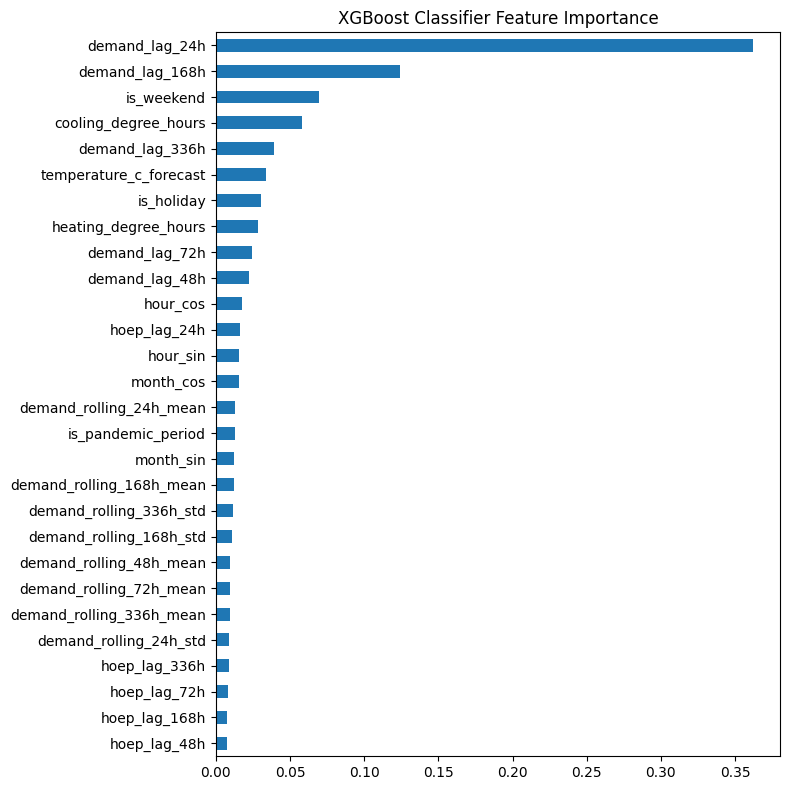

In [18]:
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 8))
importances.plot(kind='barh', ax=ax)
ax.invert_yaxis()
plt.title('XGBoost Classifier Feature Importance')
plt.tight_layout()
plt.show()

## 6. Tuning the decision threshold for Critical specifically

XGBoost's default `.predict()` assigns each row to whichever class has the
single highest probability. Since `.predict_proba()` gives us the actual
probability for each class, we can deliberately lower the bar for calling
something "Critical" specifically, trading some precision for better recall
on the one class where missing a real event is most costly.

Again, we'll pick the threshold using the VALIDATION set (2022), not a test
year as looking at how well it performs on `test_2023` would mean fitting
a decision to the exact data we're supposed to be evaluating on afterward.

Threshold for ~85% recall: 0.301  (precision at this point: 0.294)


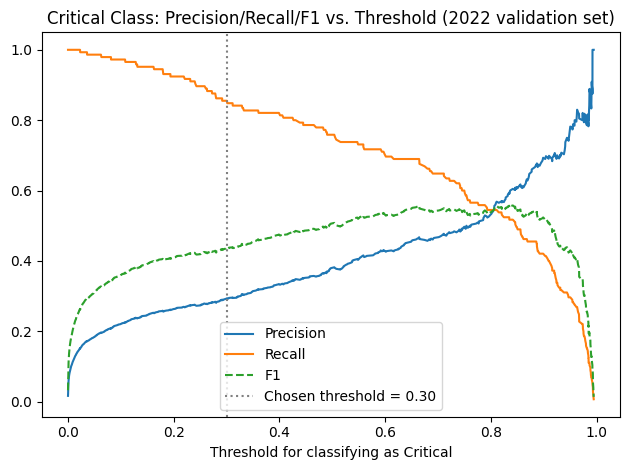

Default threshold: 0.5  ->  chosen threshold: 0.301


In [ ]:
from sklearn.metrics import precision_recall_curve

critical_idx = regime_labels.index('Critical')

# Get prediction probabilities and ground truth labels
val_proba = clf.predict_proba(xgb_val_df[feature_cols])
val_is_critical = (xgb_val_df['regime'] == 'Critical').astype(int)

# Evaluate precision and recall pairs for all possible thresholds
precisions, recalls, thresholds = precision_recall_curve(val_is_critical, val_proba[:, critical_idx])

# Calculate the F1 scores across all possible thresholds
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores[:-1])  # last point has no corresponding threshold
best_threshold = thresholds[best_idx]

# Find the threshold giving recall closest to our arbitrary goal of 0.85,
# rather than trusting F1-maximization to align with our actual priority
target_recall = 0.85
valid_idxs = np.where(recalls[:-1] >= target_recall)[0]
best_idx = valid_idxs[-1] if len(valid_idxs) else 0  # select the highest threshold that still hits the target recall
best_threshold = thresholds[best_idx]
print(f"Threshold for ~{target_recall:.0%} recall: {best_threshold:.3f}  (precision at this point: {precisions[best_idx]:.3f})")

fig, ax = plt.subplots()
ax.plot(thresholds, precisions[:-1], label='Precision')
ax.plot(thresholds, recalls[:-1], label='Recall')
ax.plot(thresholds, f1_scores[:-1], label='F1', linestyle='--')
ax.axvline(best_threshold, color='gray', linestyle=':', label=f'Chosen threshold = {best_threshold:.2f}')
ax.set_xlabel('Threshold for classifying as Critical')
plt.title('Critical Class: Precision/Recall/F1 vs. Threshold (2022 validation set)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Default threshold: 0.5  ->  chosen threshold: {best_threshold:.3f}")

## 7. Applying the tuned threshold to all three held-out test years

For each row: if P(Critical) exceeds the chosen threshold, classify as
Critical; otherwise, fall back to whichever of the other three classes has
the highest probability. Applying the same threshold (chosen once, from
validation data) to 2023, 2024, and 2025, not re-tuned per year, which
would again be a form of peeking at each test year individually.

In [ ]:
# Function to override the standard argmax method (choosing highest probability) so we can prioritize Critical performance
def classify_with_custom_threshold(proba, critical_idx, threshold):
    # Create placeholders for predictions
    n = proba.shape[0]
    preds = np.full(n, -1, dtype=int)

    # Check if predicted probability for Critical class exceed our threshold
    is_critical = proba[:, critical_idx] > threshold
    preds[is_critical] = critical_idx

    # For all non-Critical classes, assign highest probability as per usual
    other_idx = [i for i in range(proba.shape[1]) if i != critical_idx]
    non_critical_proba = proba[~is_critical][:, other_idx]
    preds[~is_critical] = np.array(other_idx)[np.argmax(non_critical_proba, axis=1)]
    return preds


for year_label, test_set in [('2023', test_2023), ('2024', test_2024), ('2025 (partial)', test_2025)]:
    # Generate probablities and apply threshold logic
    proba = clf.predict_proba(test_set[feature_cols])
    custom_preds = classify_with_custom_threshold(proba, critical_idx, best_threshold)

    # Convert to text labels
    y_true = pd.Categorical.from_codes(test_set['regime'].cat.codes, categories=regime_labels)
    y_pred = pd.Categorical.from_codes(custom_preds, categories=regime_labels)

    print(f"=== XGBoost (tuned threshold) {year_label} ===")
    print(classification_report(y_true, y_pred, labels=regime_labels, zero_division=0))

=== XGBoost (tuned threshold) 2023 ===
              precision    recall  f1-score   support

         Low       0.84      0.92      0.88      2499
      Normal       0.90      0.83      0.86      4965
        Peak       0.67      0.69      0.68      1179
    Critical       0.48      0.88      0.62       117

    accuracy                           0.84      8760
   macro avg       0.72      0.83      0.76      8760
weighted avg       0.85      0.84      0.84      8760

=== XGBoost (tuned threshold) 2024 ===
              precision    recall  f1-score   support

         Low       0.80      0.92      0.86      2193
      Normal       0.90      0.83      0.86      4891
        Peak       0.74      0.74      0.74      1453
    Critical       0.65      0.76      0.70       247

    accuracy                           0.83      8784
   macro avg       0.77      0.81      0.79      8784
weighted avg       0.84      0.83      0.84      8784

=== XGBoost (tuned threshold) 2025 (partial) ===
   

## Summary

Three approaches were compared for identifying Critical demand hours, and
the results made clear that the "best" model isn't just whichever one
looks best on aggregate accuracy:

| Approach | Critical recall (2023/24/25) | Critical precision (2023/24/25) |
|---|---|---|
| XGBoost, default 0.5 threshold | 0.76 / 0.63 / 0.60 | 0.59 / 0.72 / 0.71 |
| Logistic Regression | 0.90 / 0.78 / 0.95 | 0.57 / 0.60 / 0.32 |
| XGBoost, tuned threshold (0.301) | 0.88 / 0.76 / 0.75 | 0.48 / 0.65 / 0.58 |

**The tuned-threshold XGBoost model is the one we will carry forward.** It
delivers most of the recall improvement of Logistic Regression, without
that model's precision collapse in 2025 (0.32 -- meaning two-thirds of its
Critical alerts were false alarms). Choosing recall over raw accuracy was a deliberate
decision, justified by the reasoning that missing a genuine Critical hour
is operationally more costly than a false alarm on a borderline Peak hour.
The threshold itself was chosen using ONLY the 2022 validation set,
never by looking at the test years' own results. The threshold's achieved
recall (0.88/0.76/0.75) doesn't consistently hit the 85% target it was
tuned for. This is expected, given Critical's small per-year sample sizes
(117/247/57 hours) make the exact precision-recall trade-off somewhat
noisy year to year. The *direction* of improvement over the default
threshold is robust across all three years, while the *exact number* achieved
is not guaranteed to replicate precisely.